## About
this way the autoencoder works somehow but the shape it learned is poor quality and it just does not fit even though it finds outliers similarly to linear model or ML algorithms

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn

In [2]:
from anomaly_detection.utils.plotting_styles import apply_global_style

In [3]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.preprocess import drop_empty_histograms
from anomaly_detection.utils.preprocess import minmax_scale_per_sample

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [5]:
dataset_no_outs = torch.from_numpy(dataset_no_outs)
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
full_dataset = torch.from_numpy(full_dataset)

dataset_no_outs = dataset_no_outs.to(torch.float32)
X_train = X_train.to(torch.float32)
X_test = X_test.to(torch.float32)
full_dataset = full_dataset.to(torch.float32)

In [6]:
from torch.utils.data import Dataset, DataLoader

class HistDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        x = self.df[idx]

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        
        x = x.unsqueeze(0)
        return x

In [7]:
pt = dataset[34]

# to get the actual lenght
pt_len = len(pt)
print(type(pt))
pt = torch.tensor(pt.reshape(1, 1, pt_len))
encoder = nn.Sequential(
            nn.Conv1d(1, 1, kernel_size=3),  
            nn.BatchNorm1d(1),
            nn.ReLU(),
            
            nn.Conv1d(1, 1, kernel_size=3, stride=2, padding=1),  
            nn.BatchNorm1d(1),
            nn.ReLU(),

            
            nn.Conv1d(1, 1, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm1d(1),
            nn.Sigmoid()
        )

print(f"The encoded data shape: {encoder(pt).shape}")

<class 'numpy.ndarray'>
The encoded data shape: torch.Size([1, 1, 24])


In [8]:
class AE(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 2, kernel_size=3, padding=1),  
            nn.BatchNorm1d(2),
            nn.ReLU(),
            
            nn.Conv1d(2, 4, kernel_size=3, stride=2, padding=1),  
            nn.BatchNorm1d(4),
            nn.ReLU(),

            nn.Conv1d(4, 8, kernel_size=3, padding=1),  
            nn.BatchNorm1d(8),
            nn.ReLU(),

            nn.Conv1d(8, 16, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.Conv1d(16, 32, kernel_size=3, padding=1),  
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Conv1d(32, 32, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm1d(32),
            nn.Sigmoid())


        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(32, 32, kernel_size=3, stride=2, padding=1),  
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            nn.ConvTranspose1d(32, 16, kernel_size=3, padding=1),  
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.ConvTranspose1d(16, 8, kernel_size=3, stride=2, padding=1),  
            nn.BatchNorm1d(8),
            nn.ReLU(),
            
            nn.ConvTranspose1d(8, 4, kernel_size=3, padding=1),
            nn.BatchNorm1d(4),
            nn.ReLU(),

            nn.ConvTranspose1d(4, 2, kernel_size=3, stride=2, padding=1),  
            nn.BatchNorm1d(2),
            nn.ReLU(),
            
            nn.ConvTranspose1d(2, 1, kernel_size=3, padding=1),
            nn.BatchNorm1d(1),
            nn.ReLU(),

            nn.Linear(89, 96),
            nn.Sigmoid()
            )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [9]:
batch_size = 32
train_dataset = HistDataset(X_train)
test_dataset = HistDataset(X_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

ae_conv = AE()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(params=ae_conv.parameters(), lr=0.0005)

In [10]:
from anomaly_detection.utils.autoencoders import train_ae

ae_conv.train()
train_losses, val_losses, ae_conv = train_ae(n_epochs=250, 
                                             dataloader=train_loader, 
                                             model=ae_conv, 
                                             val_loader=test_loader, 
                                             optimizer=optimizer, 
                                             criterion=criterion,
                                             add_regularization=True,
                                             lam=0.0001,
                                             save_checkpoints=True,
                                             saving_after_epoch=20,
                                             model_name="ae_conv_v2",
                                             input_dim=96,
                                             latent_dim=14)

[Checkpoint created] saved weights in epoch: 21
[Checkpoint created] saved weights in epoch: 24
[Checkpoint created] saved weights in epoch: 32
[Checkpoint created] saved weights in epoch: 52
[Checkpoint created] saved weights in epoch: 60
[Checkpoint created] saved weights in epoch: 75
[Checkpoint created] saved weights in epoch: 99
[Checkpoint created] saved weights in epoch: 173


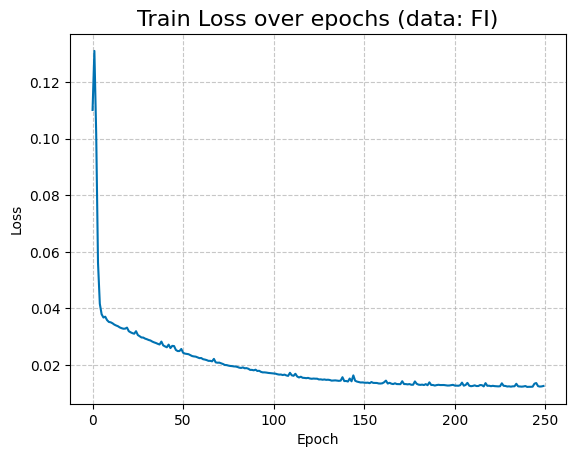

In [11]:
apply_global_style()
plt.title("Train Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(train_losses)), train_losses)
plt.show()

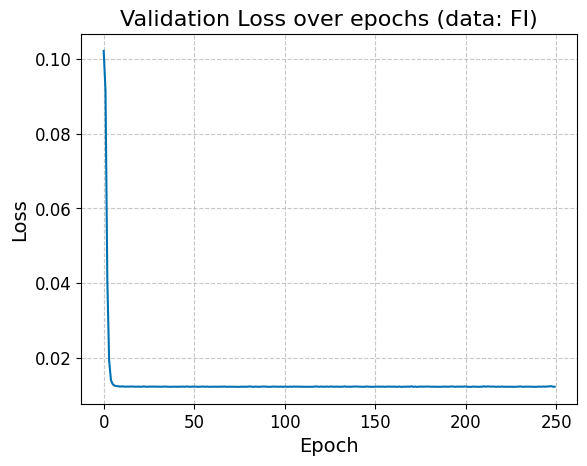

In [12]:
apply_global_style()
plt.title("Validation Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(val_losses)), val_losses)
plt.show()

In [13]:
full_dataset = HistDataset(full_dataset)
dataloader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False)

c:\Users\hrdyj\coding\vyzkumak\mlenv\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([1, 96])) that is different to the input size (torch.Size([1, 1, 96])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


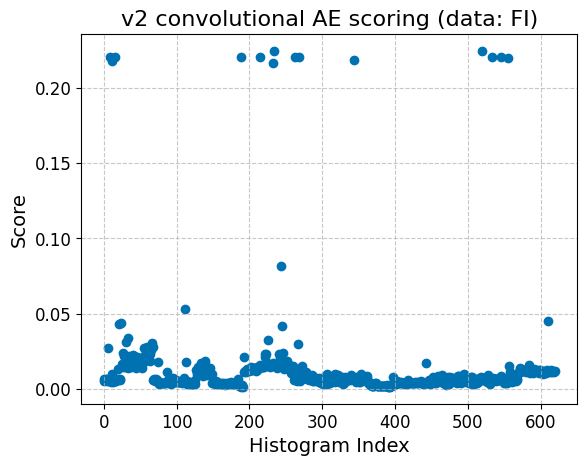

In [14]:
apply_global_style()
plt.title("v2 convolutional AE scoring (data: FI)")
plt.xlabel("Histogram Index")
plt.ylabel("Score")

model=ae_conv
model.eval()
score = []

with torch.no_grad():
    for pt in full_dataset:
        pred = ae_conv(pt.reshape(1,1,96))
        loss = criterion(pred, pt).detach().numpy()
        score.append(loss)

plt.scatter(range(len(score)), score)
plt.show()

In [15]:
outliers = np.where(np.array(score) > 0.14)
outliers

(array([  8,  11,  15, 188, 214, 233, 234, 263, 268, 344, 520, 533, 546,
        555]),)

In [16]:
import numpy as np

preds = []

with torch.no_grad():
    for idx, data in enumerate(full_dataset):
        pred = ae_conv(data.reshape(1, 1, 96)).cpu().numpy().squeeze()
        
        for p in preds:
            if np.array_equal(pred, p):
                break
        else:
            preds.append(pred)

print(f"There are {len(preds)} unique representations that model outputs")

There are 1 unique representations that model outputs


In [17]:
def plot_selected(preds, indices):
    if len(indices) != 4:
        raise ValueError("Exactly 4 indices must be provided.")

    if isinstance(preds, torch.Tensor):
        preds = preds.detach().cpu().numpy()

    preds = np.asarray(preds)

    if preds.ndim == 1:
        values = preds[indices]

        plt.figure()
        plt.bar(range(4), values)
        plt.xticks(range(4), indices)
        plt.title("Selected indices")
        plt.show()

    elif preds.ndim >= 2:
        plt.figure()
        for idx in indices:
            plt.plot(preds[idx], label=f"idx {idx}")

        plt.legend()
        plt.title("Predictions")
        apply_global_style()
        plt.show()

    else:
        raise ValueError("Unsupported tensor shape.")

plot_selected(preds, [18, 101, 257, 555])

IndexError: index 18 is out of bounds for axis 0 with size 1

<Figure size 640x480 with 0 Axes>

tensor(0.0059)


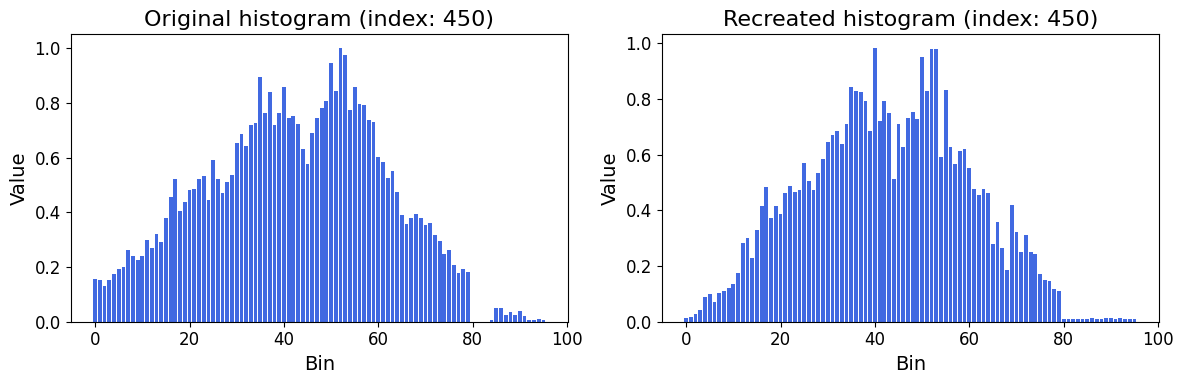

In [ ]:
idx = 450

ae_conv.eval()
pred = ae_conv(full_dataset[idx].reshape(1, 1, 96)).detach()

criterion = nn.MSELoss()
loss = criterion(pred, full_dataset[idx])
pred = pred.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(pred)), full_dataset[idx].squeeze(), zorder=1, color='royalblue')
axes[0].set_title(f"Original histogram (index: {idx})")
axes[0].set_xlabel("Bin")
axes[0].set_ylabel("Value")

axes[1].bar(range(len(pred)), pred, zorder=1, color='royalblue')
axes[1].set_title(f"Recreated histogram (index: {idx})")
axes[1].set_xlabel("Bin")
axes[1].set_ylabel("Value")
plt.tight_layout()
print(loss)
plt.show()

In [ ]:
score_dict = {idx : s for idx, s in enumerate(score)}
indexes_sorted_by_score = sorted(score_dict, key=lambda x: score_dict[x], reverse=True)

print("highest scores", indexes_sorted_by_score[:10] )
print("lowest scores", indexes_sorted_by_score[-3:])

highest scores [520, 234, 11, 8, 15, 188, 214, 263, 268, 533]
lowest scores [381, 405, 410]


In [ ]:
from anomaly_detection.config.paths import CHECKPOINT_DIR

save_model = False

if save_model:
    torch.save({
        "model_state_dict": ae_conv.state_dict(),
        "config": {
            "input_dim": 96,
            "latent_dim": 14,
            "num_latent_space_embeddings" : 32
        }
    }, f"{CHECKPOINT_DIR}/conv_autoenc_v2.pth")